# 06. Customer Segmentation

This notebook creates business-friendly customer segments using RFM-style behavior signals and 90-day inactivity risk. The output supports retention decisioning by identifying which customer groups are loyal, newly acquired, dormant, occasional, or high-value but at risk.

**Primary inputs**

- `data/processed/customer_modeling_90d.csv`

**Primary outputs**

- `data/processed/customer_segments.csv`
- `data/processed/segment_summary.csv`

**Analytical goal**

Create interpretable customer groups that can guide retention campaigns, customer lifecycle messaging, and future model monitoring.

## 1. Setup

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid", context="notebook")

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name.lower() == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

processed_path = PROJECT_ROOT / "data" / "processed"
input_path = processed_path / "customer_modeling_90d.csv"
segmentation_output = processed_path / "customer_segments.csv"
summary_output = processed_path / "segment_summary.csv"

print(f"Project root: {PROJECT_ROOT}")
print(f"Input file: {input_path}")

Project root: C:\Learning\BANA8083\AI-retention-decision-support
Input file: C:\Learning\BANA8083\AI-retention-decision-support\data\processed\customer_modeling_90d.csv


## 2. Load Customer Modeling Data

In [3]:
if not input_path.exists():
    raise FileNotFoundError(
        f"Could not find {input_path}. Run the feature engineering notebook first, "
        "or confirm that customer_modeling_90d.csv is in data/processed."
    )

customer_model = pd.read_csv(input_path)

print(f"Rows: {customer_model.shape[0]:,}")
print(f"Columns: {customer_model.shape[1]:,}")
customer_model.head()

Rows: 5,281
Columns: 21


,CustomerID,first_purchase_date,last_purchase_date,frequency,monetary_value,avg_order_value,total_quantity,avg_basket_quantity,avg_products_per_order,recency,customer_lifetime_days,product_diversity,description_diversity,primary_country,return_cancel_rows,return_cancel_invoices,return_cancel_quantity,return_cancel_value,return_cancel_rate,active_90d,inactive_90d
0,12346,2009-12-14 08:34:00,2011-01-18 10:01:00,12,77556.46,6463.038333,74285,6190.416667,2.833333,235,400,27,26,United Kingdom,13.0,5.0,74232.0,77608.20,0.416667,0,1
1,12347,2010-10-31 14:20:00,2011-08-02 08:48:00,6,3402.39,567.065000,2099,349.833333,27.333333,39,274,107,107,Iceland,0.0,0.0,0.0,0.00,0.000000,1,0
2,12348,2010-09-27 14:59:00,2011-04-05 10:47:00,4,1709.40,427.350000,2497,624.250000,11.000000,158,189,25,28,Finland,0.0,0.0,0.0,0.00,0.000000,1,0
3,12349,2010-04-29 13:20:00,2010-10-28 08:23:00,3,2671.14,890.380000,993,331.000000,34.000000,317,181,90,94,Italy,5.0,1.0,5.0,24.15,0.333333,1,0
4,12350,2011-02-02 16:01:00,2011-02-02 16:01:00,1,334.40,334.400000,197,197.000000,17.000000,219,0,17,17,Norway,0.0,0.0,0.0,0.00,0.000000,0,1


In [4]:
required_columns = [
    "CustomerID",
    "recency",
    "frequency",
    "monetary_value",
    "customer_lifetime_days",
    "product_diversity",
    "inactive_90d",
]

missing_columns = [col for col in required_columns if col not in customer_model.columns]
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

customer_model[required_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
CustomerID,5281.0,15324.100170,1712.323865,12346.0,13850.00,15313.00,16807.00,18287.00
recency,5281.0,207.282901,175.007174,0.0,49.00,164.00,326.00,648.00
frequency,5281.0,5.745692,11.464582,1.0,1.00,3.00,6.00,309.00
monetary_value,5281.0,2637.863286,12225.544955,2.9,318.24,783.58,2078.54,456780.49
customer_lifetime_days,5281.0,224.148457,218.803611,0.0,0.00,170.00,417.00,646.00
product_diversity,5281.0,74.356751,104.968606,1.0,18.00,41.00,92.00,2182.00
inactive_90d,5281.0,0.565991,0.495673,0.0,0.00,1.00,1.00,1.00


## 3. Data Quality Check

In [5]:
quality_summary = pd.DataFrame({
    "dtype": customer_model.dtypes.astype(str),
    "missing_values": customer_model.isna().sum(),
    "missing_pct": customer_model.isna().mean().mul(100).round(2),
    "unique_values": customer_model.nunique(),
}).sort_values(["missing_values", "unique_values"], ascending=[False, True])

quality_summary

,dtype,missing_values,missing_pct,unique_values
active_90d,int64,0,0.0,2
inactive_90d,int64,0,0.0,2
return_cancel_invoices,float64,0,0.0,37
primary_country,object,0,0.0,41
return_cancel_rows,float64,0,0.0,77
frequency,int64,0,0.0,83
return_cancel_rate,float64,0,0.0,213
return_cancel_quantity,float64,0,0.0,270
product_diversity,int64,0,0.0,415
description_diversity,int64,0,0.0,438


In [6]:
duplicate_customers = customer_model["CustomerID"].duplicated().sum()
inactive_rate = customer_model["inactive_90d"].mean()

print(f"Duplicate CustomerID rows: {duplicate_customers:,}")
print(f"Overall 90-day inactivity rate: {inactive_rate:.1%}")

Duplicate CustomerID rows: 0
Overall 90-day inactivity rate: 56.6%


## 4. Create RFM Scores

RFM scoring converts behavioral measures into simple 1 to 5 scores:

- **Recency score:** lower recency is better because the customer purchased more recently.
- **Frequency score:** higher frequency is better.
- **Monetary score:** higher monetary value is better.

Ranking before `qcut` keeps the scoring stable when many customers have the same value.

In [7]:
segmentation = customer_model.copy()


def quantile_score(series, labels):
    # Rank first to avoid duplicate-bin issues when many customers share the same value.
    ranked = series.rank(method="first")
    return pd.qcut(ranked, q=len(labels), labels=labels).astype(int)


segmentation["R_score"] = quantile_score(segmentation["recency"], labels=[5, 4, 3, 2, 1])
segmentation["F_score"] = quantile_score(segmentation["frequency"], labels=[1, 2, 3, 4, 5])
segmentation["M_score"] = quantile_score(segmentation["monetary_value"], labels=[1, 2, 3, 4, 5])

segmentation["RFM_score"] = segmentation[["R_score", "F_score", "M_score"]].sum(axis=1)
segmentation["RFM_average"] = segmentation[["R_score", "F_score", "M_score"]].mean(axis=1).round(2)

segmentation[
    ["CustomerID", "recency", "frequency", "monetary_value", "R_score", "F_score", "M_score", "RFM_score"]
].head(10)

,CustomerID,recency,frequency,monetary_value,R_score,F_score,M_score,RFM_score
0,12346,235,12,77556.46,3,5,5,13
1,12347,39,6,3402.39,4,4,5,13
2,12348,158,4,1709.40,3,3,4,10
3,12349,317,3,2671.14,2,3,5,10
4,12350,219,1,334.40,3,1,2,6
5,12351,284,1,300.93,2,1,2,5
6,12352,171,7,1905.61,3,4,4,11
7,12353,113,2,406.76,3,2,2,7
8,12354,141,1,1079.40,3,1,3,7
9,12355,123,2,947.61,3,2,3,8


In [8]:
rfm_distribution = (
    segmentation["RFM_score"]
    .value_counts()
    .sort_index()
    .rename_axis("RFM_score")
    .reset_index(name="customers")
)
rfm_distribution["customer_pct"] = rfm_distribution["customers"].div(len(segmentation)).mul(100).round(2)

rfm_distribution

,RFM_score,customers,customer_pct
0,3,258,4.89
1,4,417,7.90
2,5,474,8.98
3,6,457,8.65
4,7,452,8.56
5,8,449,8.50
6,9,432,8.18
7,10,407,7.71
8,11,409,7.74
9,12,371,7.03


## 5. Assign Business-Friendly Segments

In [9]:
NEW_CUSTOMER_DAYS = 30
AT_RISK_RECENCY_DAYS = 90
DORMANT_RECENCY_DAYS = 180


def assign_customer_segment(row):
    recency = row["recency"]
    lifetime = row["customer_lifetime_days"]
    r_score = row["R_score"]
    f_score = row["F_score"]
    m_score = row["M_score"]

    if lifetime <= NEW_CUSTOMER_DAYS and recency <= NEW_CUSTOMER_DAYS:
        return "New Customers"
    if r_score >= 4 and f_score >= 4 and m_score >= 4:
        return "Loyal Customers"
    if m_score >= 4 and recency > AT_RISK_RECENCY_DAYS:
        return "High-Value At-Risk Customers"
    if recency > DORMANT_RECENCY_DAYS:
        return "Dormant Customers"
    if f_score <= 2 and m_score <= 2:
        return "Low-Value Occasional Customers"
    return "Regular Customers"


segmentation["customer_segment"] = segmentation.apply(assign_customer_segment, axis=1)

segment_order = [
    "Loyal Customers",
    "Regular Customers",
    "New Customers",
    "Low-Value Occasional Customers",
    "High-Value At-Risk Customers",
    "Dormant Customers",
]

segmentation["customer_segment"] = pd.Categorical(
    segmentation["customer_segment"],
    categories=segment_order,
    ordered=True,
)

segmentation["customer_segment"].value_counts().reindex(segment_order).dropna()

customer_segment
Loyal Customers                   1212
Regular Customers                  810
New Customers                      114
Low-Value Occasional Customers     359
High-Value At-Risk Customers       788
Dormant Customers                 1998
Name: count, dtype: int64

## 6. Segment Summary

In [10]:
segment_summary = (
    segmentation.groupby("customer_segment", observed=False)
    .agg(
        customers=("CustomerID", "count"),
        inactive_rate=("inactive_90d", "mean"),
        avg_recency=("recency", "mean"),
        median_recency=("recency", "median"),
        avg_frequency=("frequency", "mean"),
        median_frequency=("frequency", "median"),
        avg_monetary_value=("monetary_value", "mean"),
        median_monetary_value=("monetary_value", "median"),
        avg_order_value=("avg_order_value", "mean"),
        avg_product_diversity=("product_diversity", "mean"),
        avg_customer_lifetime_days=("customer_lifetime_days", "mean"),
        avg_rfm_score=("RFM_score", "mean"),
    )
    .reset_index()
)

segment_summary["customer_percentage"] = segment_summary["customers"].div(segment_summary["customers"].sum())
segment_summary["inactive_customers_est"] = (
    segment_summary["customers"] * segment_summary["inactive_rate"]
).round(0).astype(int)

segment_summary = segment_summary.sort_values("inactive_rate", ascending=False).reset_index(drop=True)

formatted_segment_summary = segment_summary.copy()
formatted_segment_summary["inactive_rate"] = formatted_segment_summary["inactive_rate"].map("{:.1%}".format)
formatted_segment_summary["customer_percentage"] = formatted_segment_summary["customer_percentage"].map("{:.1%}".format)
for col in [
    "avg_recency",
    "median_recency",
    "avg_frequency",
    "median_frequency",
    "avg_monetary_value",
    "median_monetary_value",
    "avg_order_value",
    "avg_product_diversity",
    "avg_customer_lifetime_days",
    "avg_rfm_score",
]:
    formatted_segment_summary[col] = formatted_segment_summary[col].round(2)

formatted_segment_summary

,customer_segment,customers,inactive_rate,avg_recency,median_recency,avg_frequency,median_frequency,avg_monetary_value,median_monetary_value,avg_order_value,avg_product_diversity,avg_customer_lifetime_days,avg_rfm_score,customer_percentage,inactive_customers_est
0,Dormant Customers,1998,79.9%,377.85,341.0,1.75,1.0,400.52,328.99,250.92,29.75,65.08,5.52,37.8%,1596
1,Low-Value Occasional Customers,359,66.6%,103.39,103.0,1.29,1.0,266.86,251.21,216.40,20.03,52.49,6.58,6.8%,239
2,High-Value At-Risk Customers,788,56.2%,249.31,232.0,6.14,5.0,3183.79,1921.84,677.08,97.36,279.17,10.46,14.9%,443
3,Regular Customers,810,52.6%,75.52,71.0,3.33,3.0,850.68,754.94,308.75,49.74,267.22,9.93,15.3%,426
4,New Customers,114,40.4%,14.09,15.0,1.23,1.0,438.78,299.52,362.65,28.13,3.60,8.38,2.2%,46
5,Loyal Customers,1212,19.7%,35.78,29.0,15.44,10.0,8074.76,3636.99,450.68,169.83,493.40,13.94,23.0%,239


## 7. Segment Visuals

The first chart shows segment size. The second chart compares inactivity risk, with the overall inactivity rate shown as a reference line.

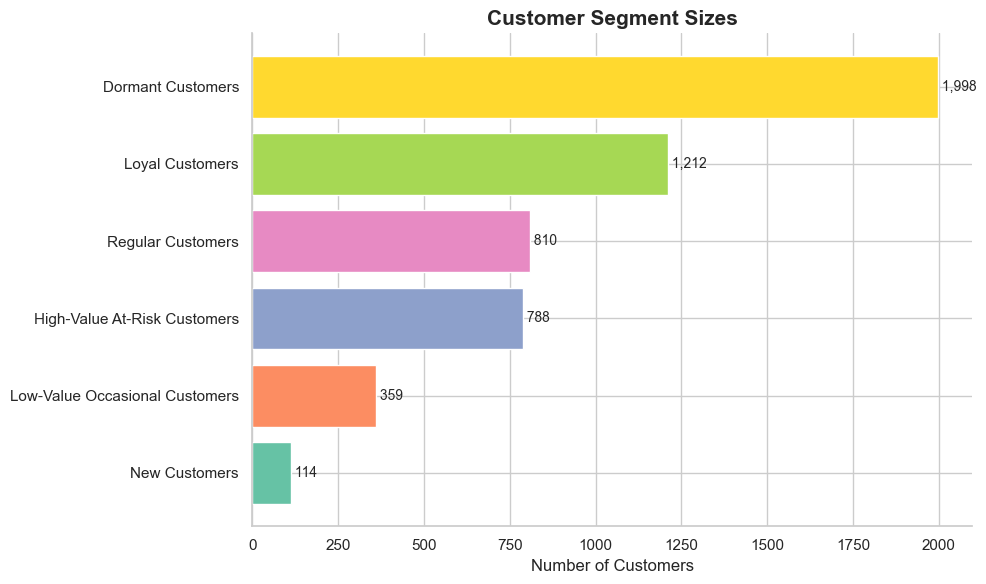

In [11]:
segment_counts = (
    segmentation["customer_segment"]
    .value_counts()
    .reindex(segment_order)
    .dropna()
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 6))
colors = sns.color_palette("Set2", n_colors=len(segment_counts))

ax.barh(segment_counts.index.astype(str), segment_counts.values, color=colors)
ax.set_title("Customer Segment Sizes", fontsize=15, fontweight="bold")
ax.set_xlabel("Number of Customers")
ax.set_ylabel("")

for i, value in enumerate(segment_counts.values):
    ax.text(value, i, f" {value:,.0f}", va="center", fontsize=10)

sns.despine()
plt.tight_layout()
plt.show()

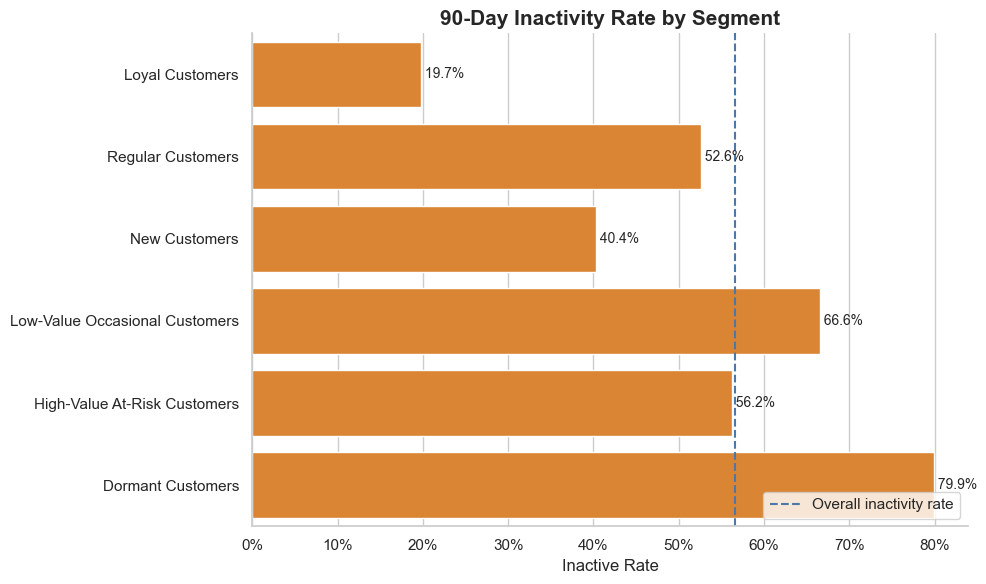

In [12]:
segment_risk = segment_summary.sort_values("inactive_rate", ascending=True).copy()
overall_inactive_rate = segmentation["inactive_90d"].mean()

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=segment_risk,
    y="customer_segment",
    x="inactive_rate",
    color="#F58518",
    ax=ax,
)

ax.axvline(overall_inactive_rate, color="#4C78A8", linestyle="--", linewidth=1.5, label="Overall inactivity rate")
ax.set_title("90-Day Inactivity Rate by Segment", fontsize=15, fontweight="bold")
ax.set_xlabel("Inactive Rate")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.legend(loc="lower right")

for patch in ax.patches:
    width = patch.get_width()
    ax.text(width, patch.get_y() + patch.get_height() / 2, f" {width:.1%}", va="center", fontsize=10)

sns.despine()
plt.tight_layout()
plt.show()

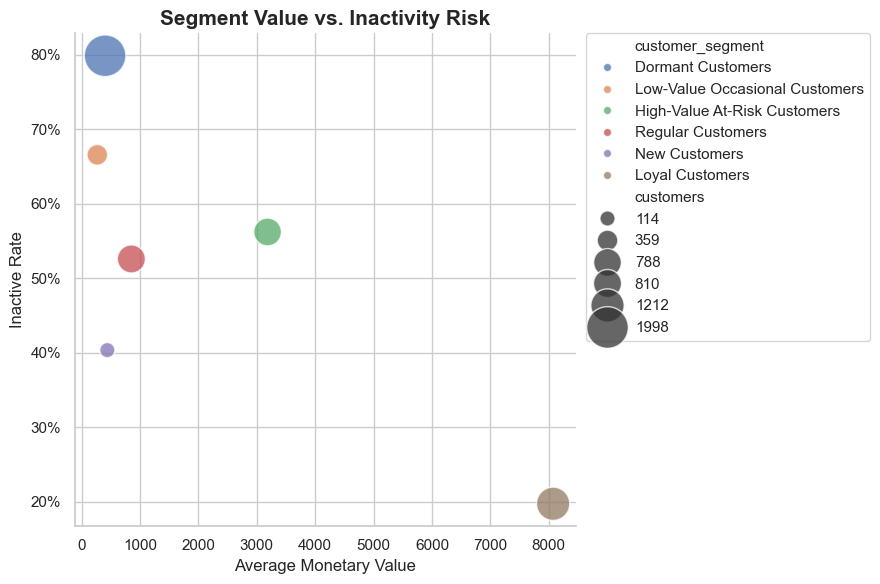

In [13]:
fig, ax = plt.subplots(figsize=(9, 6))
plot_df = segment_summary.copy()
plot_df["customer_segment"] = plot_df["customer_segment"].astype(str)

sns.scatterplot(
    data=plot_df,
    x="avg_monetary_value",
    y="inactive_rate",
    size="customers",
    hue="customer_segment",
    sizes=(120, 900),
    alpha=0.75,
    ax=ax,
)

ax.set_title("Segment Value vs. Inactivity Risk", fontsize=15, fontweight="bold")
ax.set_xlabel("Average Monetary Value")
ax.set_ylabel("Inactive Rate")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)

sns.despine()
plt.tight_layout()
plt.show()

## 8. Recommended Actions by Segment

In [16]:
segment_actions = {
    "Loyal Customers": "Protect with loyalty benefits, early access, and referral offers.",
    "Regular Customers": "Nurture with personalized cross-sell and replenishment reminders.",
    "New Customers": "Focus on onboarding, second-purchase prompts, and welcome messaging.",
    "Low-Value Occasional Customers": "Use low-cost automated campaigns and targeted bundles.",
    "High-Value At-Risk Customers": "Prioritize win-back outreach, service recovery, and high-touch offers.",
    "Dormant Customers": "Use reactivation campaigns, but cap spend unless expected value is strong."
}

segment_summary["inactive_customers_est"] = (
    segment_summary["customers"] * segment_summary["inactive_rate"]
).round(0).astype(int)

segment_recommendations = segment_summary[
    [
        "customer_segment",
        "customers",
        "customer_percentage",
        "inactive_rate",
        "avg_monetary_value",
        "inactive_customers_est"
    ]
].copy()

segment_recommendations["recommended_action"] = (
    segment_recommendations["customer_segment"].astype(str).map(segment_actions)
)

segment_recommendations["customer_percentage"] = (
    segment_recommendations["customer_percentage"].map("{:.1%}".format)
)

segment_recommendations["inactive_rate"] = (
    segment_recommendations["inactive_rate"].map("{:.1%}".format)
)

segment_recommendations["avg_monetary_value"] = (
    segment_recommendations["avg_monetary_value"].round(2)
)

segment_recommendations

,customer_segment,customers,customer_percentage,inactive_rate,avg_monetary_value,inactive_customers_est,recommended_action
0,Dormant Customers,1998,37.8%,79.9%,400.52,1596,"Use reactivation campaigns, but cap spend unle..."
1,Low-Value Occasional Customers,359,6.8%,66.6%,266.86,239,Use low-cost automated campaigns and targeted ...
2,High-Value At-Risk Customers,788,14.9%,56.2%,3183.79,443,"Prioritize win-back outreach, service recovery..."
3,Regular Customers,810,15.3%,52.6%,850.68,426,Nurture with personalized cross-sell and reple...
4,New Customers,114,2.2%,40.4%,438.78,46,"Focus on onboarding, second-purchase prompts, ..."
5,Loyal Customers,1212,23.0%,19.7%,8074.76,239,"Protect with loyalty benefits, early access, a..."


## 9. Save Segmentation Outputs

The detailed customer-level file supports campaign targeting. The summary file supports reporting and presentation tables.

In [17]:
processed_path.mkdir(parents=True, exist_ok=True)


def save_csv_if_changed(dataframe, output_path):
    """Save a CSV only when it is new or its contents changed."""
    new_csv = dataframe.to_csv(index=False)

    if output_path.exists():
        existing_csv = output_path.read_text(encoding="utf-8")
        if existing_csv == new_csv:
            print(f"No changes detected. Skipped save: {output_path}")
            return "unchanged"

    output_path.write_text(new_csv, encoding="utf-8")
    print(f"Saved updated file: {output_path}")
    return "updated"


recommendations_output = processed_path / "segment_recommendations.csv"

save_status = {
    "customer_segments": save_csv_if_changed(segmentation, segmentation_output),
    "segment_summary": save_csv_if_changed(segment_summary, summary_output),
    "segment_recommendations": save_csv_if_changed(segment_recommendations, recommendations_output)
}

save_status

Saved updated file: C:\Learning\BANA8083\AI-retention-decision-support\data\processed\customer_segments.csv
Saved updated file: C:\Learning\BANA8083\AI-retention-decision-support\data\processed\segment_summary.csv
Saved updated file: C:\Learning\BANA8083\AI-retention-decision-support\data\processed\segment_recommendations.csv


{'customer_segments': 'updated',
 'segment_summary': 'updated',
 'segment_recommendations': 'updated'}

## 10. Key Takeaways

- The segmentation framework turns model-ready customer features into interpretable business groups.
- High-value at-risk customers are especially important because they combine stronger monetary value with inactivity risk.
- Dormant customers may have the highest inactivity risk, but campaigns should account for expected value before investing heavily.
- Loyal customers should be protected and monitored because they represent the strongest current relationship base.
- These segments can be joined with churn or inactivity scores to prioritize retention campaigns in the decision-support app.